In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv('data/master_county.csv', dtype={'county_fips': str})
print(master.shape)
print(master.head())

(3048, 14)
  county_fips  avg_deaths  avg_crude_rate  avg_population  suppressed_years  \
0       01001   10.000000       16.733333    58325.000000                 4   
1       01003   61.000000       25.285714   238769.571429                 0   
2       01005   12.000000       48.600000    24681.285714                 6   
3       01007   11.000000       50.300000    22219.714286                 6   
4       01009   15.142857       25.657143    58868.142857                 0   

   total_years  TotTracts  PharCtTmDr  PharTmDrP  PharAvTmDr  \
0            7       17.0        17.0     100.00        9.91   
1            7       43.0        42.0      97.67        5.12   
2            7        9.0         8.0      88.89       14.71   
3            7        8.0         8.0     100.00       12.36   
4            7       16.0        16.0     100.00        6.96   

   unemployment_rate  median_income  uninsured_rate  poverty_rate  
0                2.5        69841.0             7.4          

count    1576.000000
mean       37.572692
std        21.305479
min         6.542857
25%        23.960714
50%        33.060714
75%        45.517857
max       284.850000
Name: avg_crude_rate, dtype: float64


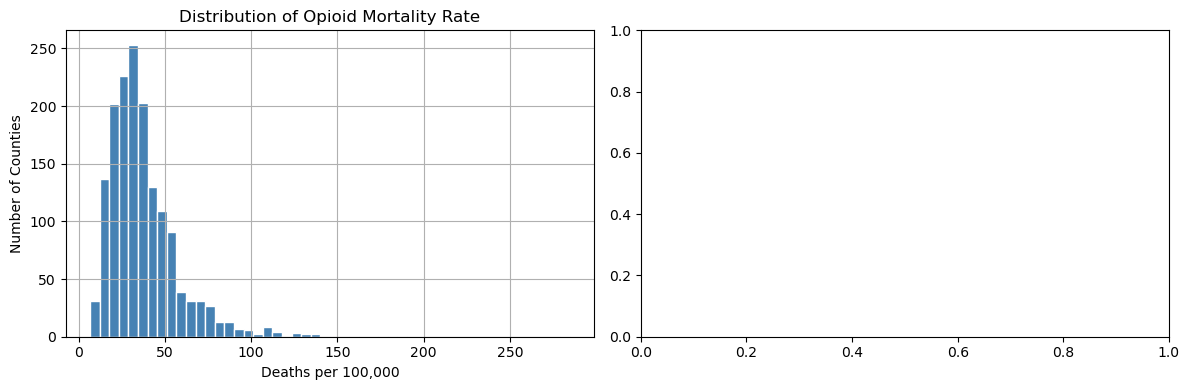

In [2]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
master['avg_crude_rate'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Opioid Mortality Rate')
plt.xlabel('Deaths per 100,000')
plt.ylabel('Number of Counties')

plt.subplot(1, 2, 2)
master['avg_crude_rate'].dropna().describe()
print(master['avg_crude_rate'].dropna().describe())

plt.tight_layout()
plt.show()

In [3]:
worst = master.nlargest(10, 'avg_crude_rate')[['county_fips', 'avg_crude_rate', 
                                                'avg_population', 'PharTmDrP', 
                                                'PharAvTmDr', 'poverty_rate']]
print(worst)

     county_fips  avg_crude_rate  avg_population  PharTmDrP  PharAvTmDr  \
2992       55078      284.850000     4394.000000      100.0       10.26   
1336       27087      184.700000     5405.285714      100.0       11.37   
1037       21129      177.700000     7288.857143      100.0       12.56   
2921       54047      157.550000    17651.714286       87.5       15.37   
2383       47067      143.800000     6755.428571      100.0       12.54   
1011       21077      136.800000     8802.142857      100.0       23.14   
1196       24510      135.285714   580293.571429      100.0        1.38   
2942       54089      132.800000    12081.714286      100.0       16.19   
2903       54011      130.785714    92353.857143      100.0        5.04   
2905       54015      128.500000     8094.142857      100.0       14.72   

      poverty_rate  
2992          21.2  
1336          20.9  
1037          28.9  
2921          30.9  
2383          31.5  
1011          14.4  
1196          20.1  
2942  

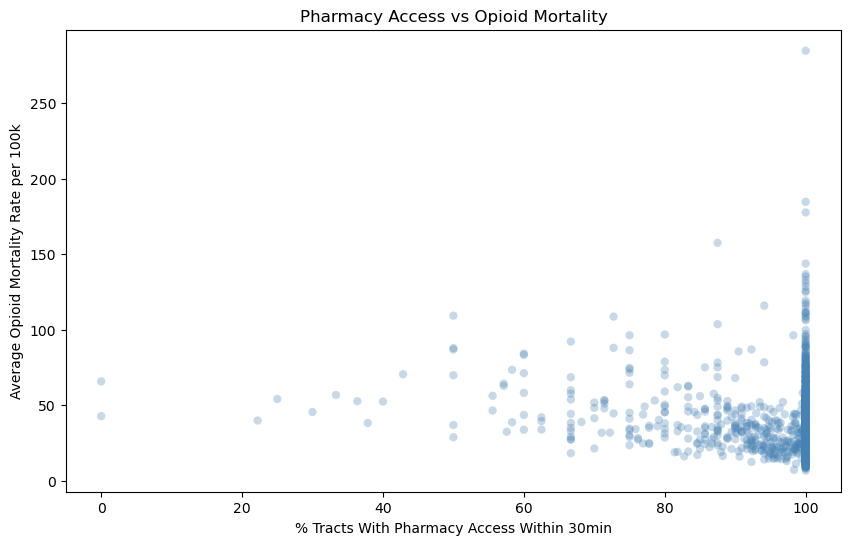

In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(master['PharTmDrP'], 
            master['avg_crude_rate'],
            alpha=0.3,
            color='steelblue',
            edgecolors='none')

plt.xlabel('% Tracts With Pharmacy Access Within 30min')
plt.ylabel('Average Opioid Mortality Rate per 100k')
plt.title('Pharmacy Access vs Opioid Mortality')
plt.show()

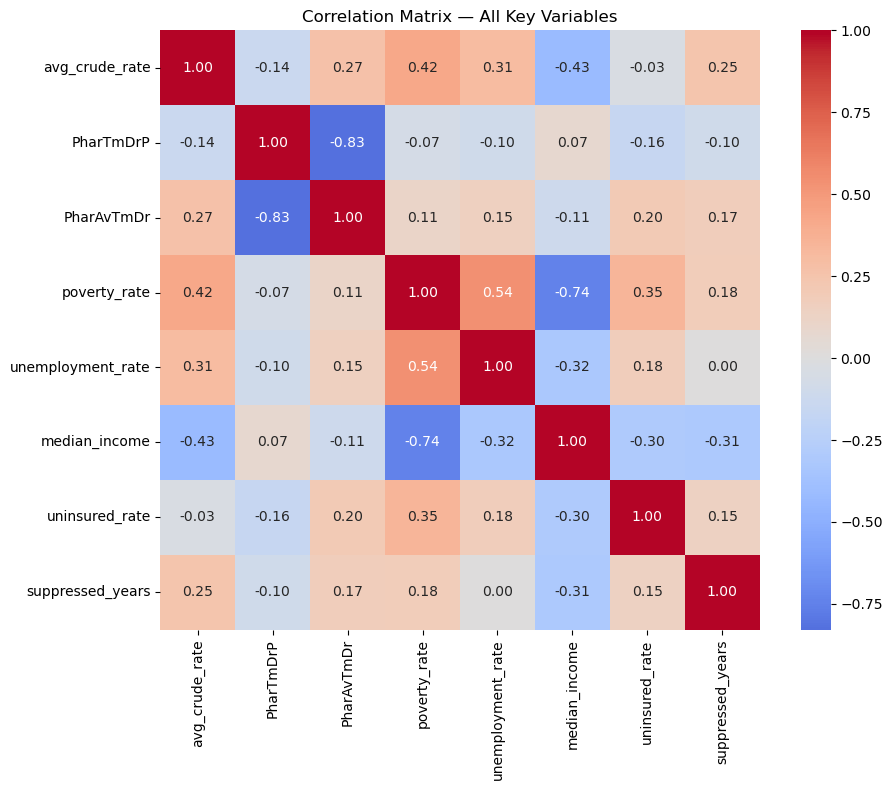

In [5]:
# Select only numeric columns with enough data
corr_cols = ['avg_crude_rate', 'PharTmDrP', 'PharAvTmDr', 
             'poverty_rate', 'unemployment_rate', 
             'median_income', 'uninsured_rate', 'suppressed_years']

corr_matrix = master[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Matrix — All Key Variables')
plt.tight_layout()
plt.show()

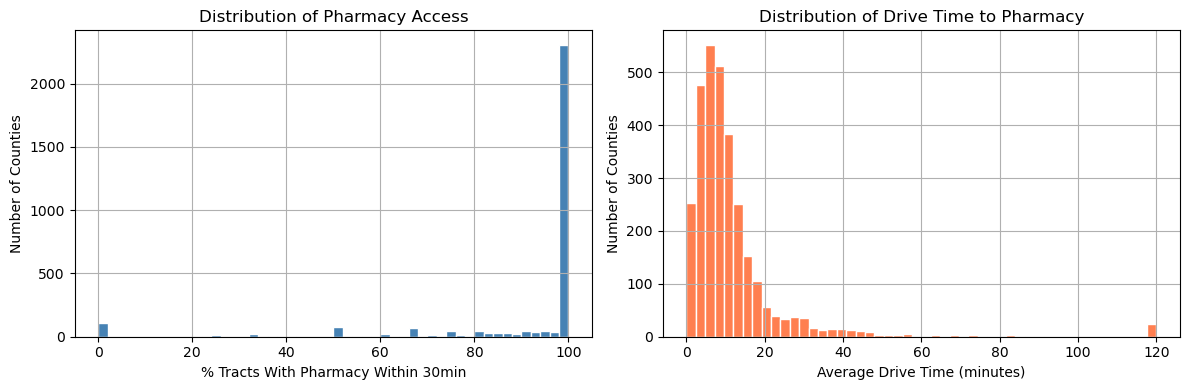

count    3048.000000
mean       91.033284
std        22.246753
min         0.000000
25%        98.672500
50%       100.000000
75%       100.000000
max       100.000000
Name: PharTmDrP, dtype: float64
count    3048.000000
mean       11.640942
std        14.244013
min         0.000000
25%         4.950000
50%         8.285000
75%        12.842500
max       120.000000
Name: PharAvTmDr, dtype: float64


In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
master['PharTmDrP'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Pharmacy Access')
plt.xlabel('% Tracts With Pharmacy Within 30min')
plt.ylabel('Number of Counties')

plt.subplot(1, 2, 2)
master['PharAvTmDr'].hist(bins=50, color='coral', edgecolor='white')
plt.title('Distribution of Drive Time to Pharmacy')
plt.xlabel('Average Drive Time (minutes)')
plt.ylabel('Number of Counties')

plt.tight_layout()
plt.show()

print(master['PharTmDrP'].describe())
print(master['PharAvTmDr'].describe())

In [7]:
desert_mask = (master['PharTmDrP'] < 50) | (master['PharAvTmDr'] > 30)
desert_counties = master[desert_mask]

print(f"Pharmacy desert counties: {len(desert_counties)}")
print(f"Percentage of all counties: {len(desert_counties)/len(master)*100:.1f}%")
print(f"\nDesert county stats:")
print(desert_counties[['avg_crude_rate', 'poverty_rate', 'median_income']].describe())

Pharmacy desert counties: 185
Percentage of all counties: 6.1%

Desert county stats:
       avg_crude_rate  poverty_rate  median_income
count       12.000000    185.000000     185.000000
mean        54.383333     15.611351   62771.751351
std         14.364804      8.154395   15652.082536
min         38.200000      2.100000   26686.000000
25%         44.800000      9.700000   53498.000000
50%         52.512500     13.800000   61222.000000
75%         59.000000     19.000000   71650.000000
max         87.800000     49.000000  143188.000000


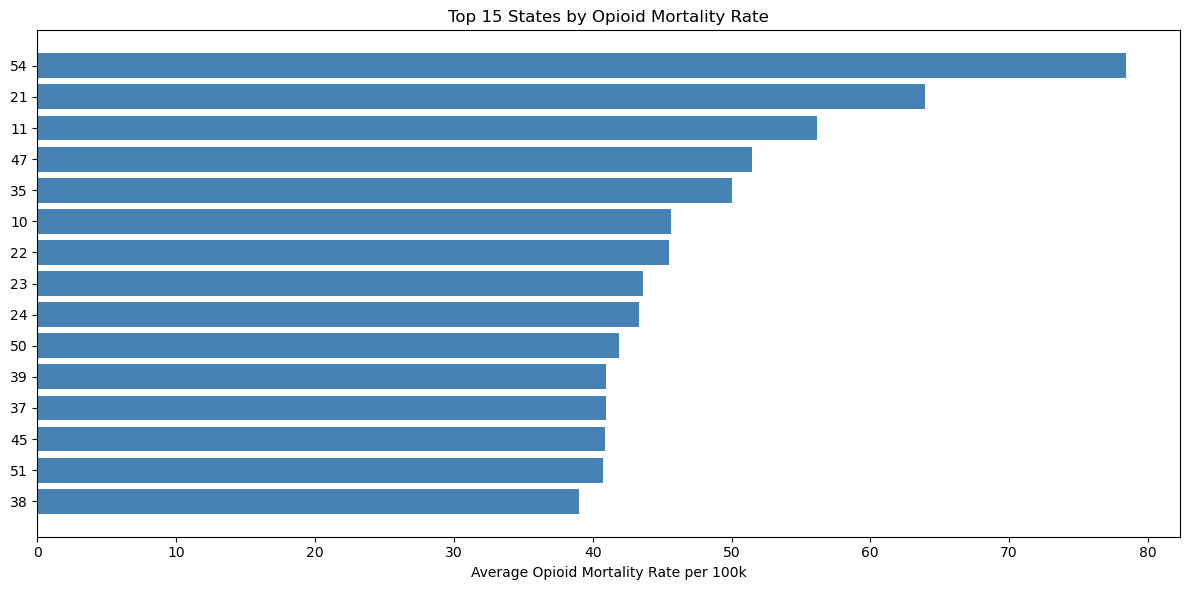

In [8]:
# Extract state FIPS from first 2 digits of county_fips
master['state_fips'] = master['county_fips'].str[:2]

# Group by state and calculate mean mortality
state_mortality = master.groupby('state_fips')['avg_crude_rate'].mean().reset_index()
state_mortality.columns = ['state_fips', 'avg_crude_rate']
state_mortality = state_mortality.dropna()
state_mortality = state_mortality.sort_values('avg_crude_rate', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(state_mortality['state_fips'], state_mortality['avg_crude_rate'], color='steelblue')
plt.xlabel('Average Opioid Mortality Rate per 100k')
plt.title('Top 15 States by Opioid Mortality Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

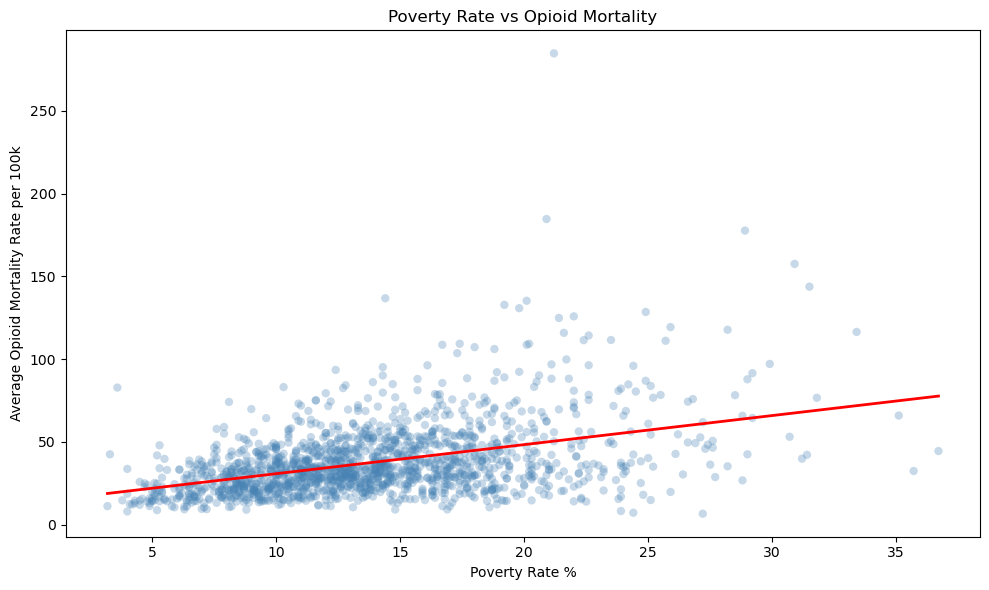

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(master['poverty_rate'], 
            master['avg_crude_rate'],
            alpha=0.3,
            color='steelblue',
            edgecolors='none')

# Add a trend line
from numpy.polynomial.polynomial import polyfit
mask = master['avg_crude_rate'].notna() & master['poverty_rate'].notna()
x = master.loc[mask, 'poverty_rate']
y = master.loc[mask, 'avg_crude_rate']
b, m = polyfit(x, y, 1)
plt.plot(sorted(x), [b + m * xi for xi in sorted(x)], color='red', linewidth=2)

plt.xlabel('Poverty Rate %')
plt.ylabel('Average Opioid Mortality Rate per 100k')
plt.title('Poverty Rate vs Opioid Mortality')
plt.tight_layout()
plt.show()

In [10]:
# Create pharmacy desert flag
master['pharmacy_desert'] = (
    (master['PharTmDrP'] < 50) | (master['PharAvTmDr'] > 30)
).astype(int)

print(master['pharmacy_desert'].value_counts())
print(f"\nDesert counties: {master['pharmacy_desert'].sum()}")
print(f"Non-desert counties: {(master['pharmacy_desert'] == 0).sum()}")

pharmacy_desert
0    2863
1     185
Name: count, dtype: int64

Desert counties: 185
Non-desert counties: 2863


In [11]:
# Flag imputed values
master['crude_rate_imputed'] = master['avg_crude_rate'].isna().astype(int)

# Impute suppressed counties with 5.0
master['avg_crude_rate'] = master['avg_crude_rate'].fillna(5.0)

print(master['crude_rate_imputed'].value_counts())
print(master['avg_crude_rate'].describe())

crude_rate_imputed
0    1576
1    1472
Name: count, dtype: int64
count    3048.000000
mean       21.842048
std        22.353010
min         5.000000
25%         5.000000
50%        14.014286
75%        33.539286
max       284.850000
Name: avg_crude_rate, dtype: float64


In [12]:
feature_cols = ['PharTmDrP', 'PharAvTmDr', 'pharmacy_desert',
                'poverty_rate', 'unemployment_rate', 'median_income',
                'uninsured_rate', 'suppressed_years', 'avg_population',
                'crude_rate_imputed']

target_col = 'avg_crude_rate'

X = master[feature_cols]
y = master[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nAny nulls in features?")
print(X.isnull().sum())

Feature matrix shape: (3048, 10)
Target shape: (3048,)

Any nulls in features?
PharTmDrP             0
PharAvTmDr            0
pharmacy_desert       0
poverty_rate          0
unemployment_rate     0
median_income         0
uninsured_rate        0
suppressed_years      0
avg_population        0
crude_rate_imputed    0
dtype: int64


In [13]:
# Save feature matrix
master.to_csv('data/master_engineered.csv', index=False)

X.to_csv('data/features.csv', index=False)
y.to_csv('data/target.csv', index=False)

print("All files saved")

All files saved
